In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Functions

In [19]:
def compute_proportions(df):
    df["seg_length"] = df["end"] - df["start"]
    summed_ibd_lens = df.groupby("ibd_status").agg(
        {"seg_length": "sum"}
    )
    ibd_props = summed_ibd_lens / summed_ibd_lens.sum()
    return ibd_props


def plot_all_chromosomes(df, title=""):

    colors = {
        "ibd0": "#D3D3D3",
        "ibd1": "#4A90D9",
        "ibd2": "#D94A4A",
    }

    all_chroms = sorted(df["chrom"].unique())
    global_max = df["end"].max()

    fig, axes = plt.subplots(
        nrows=len(all_chroms), ncols=1,
        figsize=(14, max(0.5 * len(all_chroms), 3)),
        squeeze=False
    )
    bar_height = 0.6

    for i, chrom in enumerate(all_chroms):
        ax = axes[i, 0]
        chrom_df = df[df["chrom"] == chrom]

        for _, row in chrom_df.iterrows():
            width = row["end"] - row["start"]
            ax.barh(0, width, left=row["start"], height=bar_height,
                    color=colors[row["ibd_status"]], edgecolor="none")

        ax.set_xlim(0, global_max)
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([0])
        # ax.set_yticklabels([chrom_sort_key(chrom)])
        ax.set_yticklabels([chrom], fontsize=16)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        if i < len(all_chroms) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])
        else:
            if global_max > 1_000_000:
                ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))
                ax.set_xlabel("Position (Mb)", fontsize=18)
            else:
                ax.set_xlabel("Position (bp)")

    # single legend on the first axis
    legend_patches = [mpatches.Patch(color=c, label=l.upper()) for l, c in colors.items()]
    axes[0, 0].legend(handles=legend_patches, loc="upper right", frameon=False, ncol=3, bbox_to_anchor=(1, 1.9), fontsize=16)
    fig.suptitle(title)
    plt.subplots_adjust(hspace=0.05, top=0.95, bottom=0.05)
    return fig


# Plot

In [8]:
# Plot full results. VCF of whole genome is too large to fit in repo.

In [14]:
pytruffle_calls_p = "./HG00581_vs_HG00635/ibd_segments.tsv"
pytruffle_df = pd.read_csv(pytruffle_calls_p, sep="\t")

compute_proportions(pytruffle_df)

,seg_length
ibd_status,
ibd0,0.242497
ibd1,0.524143
ibd2,0.233361


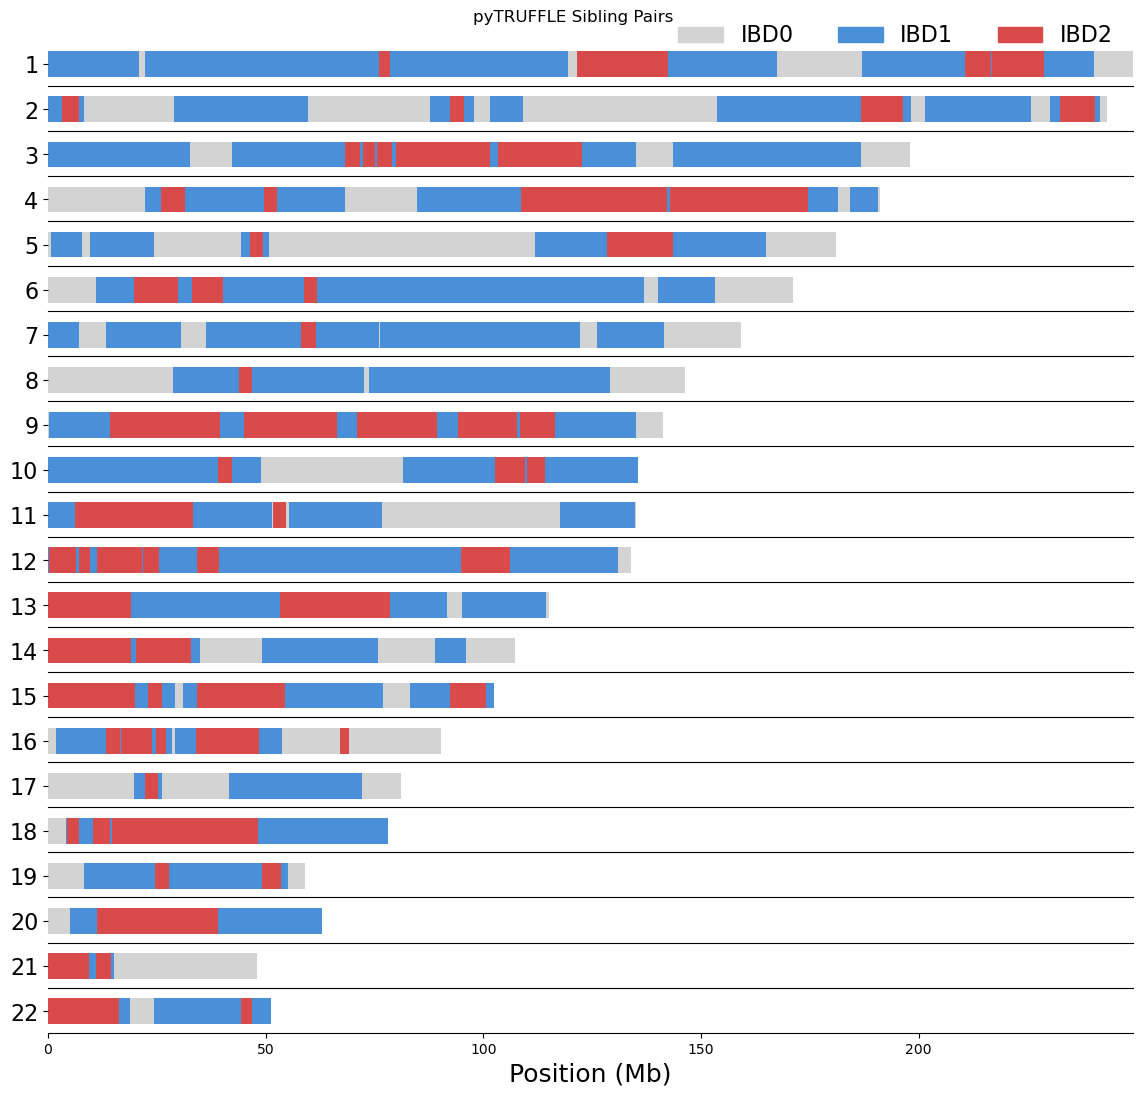

In [20]:
fig = plot_all_chromosomes(pytruffle_df, title="pyTRUFFLE Sibling Pairs")